In [1]:

import scipy
import pandas as pd
matrix=scipy.io.mmread('/home/qyyuan/project/Nature-Protocol/mouse/mm10_data/matrix.mtx')
features=pd.read_csv('/home/qyyuan/project/Nature-Protocol/mouse/mm10_data/features.txt',sep='\t',header=None)
barcodes=pd.read_csv('/home/qyyuan/project/Nature-Protocol/mouse/mm10_data/barcodes.txt',sep='\t',header=None)
label=pd.read_csv('/home/qyyuan/project/Nature-Protocol/mouse/mm10_data/mm10_label.txt',sep='\t',header=None)
label.columns=['barcode_use','label']  
from LingerGRN.preprocess import *
adata_RNA,adata_ATAC=get_adata(matrix,features,barcodes,label)# adata_RNA and adata_ATAC are scRNA and scATAC

/home/qyyuan/project/Nature-Protocol/LINGER-main/code/lingergrn-1.106/LingerGRN/preprocess.py:271: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_RNA.obs['label']=label.loc[adata_RNA.obs['barcode']]['label'].values
/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/qyyuan/project/Nature-Protocol/LINGER-main/code/lingergrn-1.106/LingerGRN/preprocess.py:274: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_ATAC.obs['label']=label.loc[adata_ATAC.obs['bar

In [2]:
import scanpy as sc
sc.pp.filter_cells(adata_RNA, min_genes=200)
sc.pp.filter_genes(adata_RNA, min_cells=3)
sc.pp.filter_cells(adata_ATAC, min_genes=200)
sc.pp.filter_genes(adata_ATAC, min_cells=3)
selected_barcode=list(set(adata_RNA.obs['barcode'].values)&set(adata_ATAC.obs['barcode'].values))
barcode_idx=pd.DataFrame(range(adata_RNA.shape[0]), index=adata_RNA.obs['barcode'].values)
adata_RNA = adata_RNA[barcode_idx.loc[selected_barcode][0]]
barcode_idx=pd.DataFrame(range(adata_ATAC.shape[0]), index=adata_ATAC.obs['barcode'].values)
adata_ATAC = adata_ATAC[barcode_idx.loc[selected_barcode][0]]

/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number
/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


In [3]:
from LingerGRN.pseudo_bulk import *
samplelist=list(set(adata_ATAC.obs['sample'].values)) # sample is generated from cell barcode 
tempsample=samplelist[0]
TG_pseudobulk=pd.DataFrame([])
RE_pseudobulk=pd.DataFrame([])
singlepseudobulk = (adata_RNA.obs['sample'].unique().shape[0]*adata_RNA.obs['sample'].unique().shape[0]>100)
for tempsample in samplelist:
    adata_RNAtemp=adata_RNA[adata_RNA.obs['sample']==tempsample]
    adata_ATACtemp=adata_ATAC[adata_ATAC.obs['sample']==tempsample]
    TG_pseudobulk_temp,RE_pseudobulk_temp=pseudo_bulk(adata_RNAtemp,adata_ATACtemp,singlepseudobulk)                
    TG_pseudobulk=pd.concat([TG_pseudobulk, TG_pseudobulk_temp], axis=1)
    RE_pseudobulk=pd.concat([RE_pseudobulk, RE_pseudobulk_temp], axis=1)
    RE_pseudobulk[RE_pseudobulk > 100] = 100

import os
if not os.path.exists('data/'):
    os.mkdir('data/')
adata_ATAC.write('data/adata_ATAC.h5ad')
adata_RNA.write('data/adata_RNA.h5ad')
TG_pseudobulk=TG_pseudobulk.fillna(0)
RE_pseudobulk=RE_pseudobulk.fillna(0)
pd.DataFrame(adata_ATAC.var['gene_ids']).to_csv('data/Peaks.txt',header=None,index=None)
TG_pseudobulk.to_csv('data/TG_pseudobulk.tsv')
RE_pseudobulk.to_csv('data/RE_pseudobulk.tsv')

/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:842: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:372: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:842: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .

In [1]:
Datadir='/home/qyyuan/data/TF_TG_software/code/mm10/'# This directory should be the same as Datadir defined in the above 'Download the general gene regulatory network' section
GRNdir=Datadir+'provide_data/'
genome='mm10'
outdir='/home/qyyuan/project/Nature-Protocol/MM10-results-p-Last/' #output dir
activef='ReLU' 
method='scNN'
import torch
import scanpy as sc
import subprocess
import pandas as pd
import os
adata_RNA=sc.read_h5ad('data/adata_RNA.h5ad')
adata_ATAC=sc.read_h5ad('data/adata_ATAC.h5ad')

In [ ]:

import LingerGRN.LINGER_tr as LINGER_tr
LINGER_tr.get_TSS(GRNdir,genome,200000) # Here, 200000 represent the largest distance of regulatory element to the TG. Other distance is supported
LINGER_tr.RE_TG_dis(outdir)
import LingerGRN.LINGER_tr as LINGER_tr
activef='ReLU' # active function chose from 'ReLU','sigmoid','tanh'
genomemap=pd.read_csv(GRNdir+'genome_map_homer.txt',sep='\t')
genomemap.index=genomemap['genome_short']
species=genomemap.loc[genome]['species_ensembl']
LINGER_tr.training(GRNdir,method,outdir,activef,species)

Overlap the regions with gene loc ...


***** WARNING: File /home/qyyuan/project/Nature-Protocol/mouse/data/Peaks.bed has inconsistent naming convention for record:
GL456211.1	116040	116319

***** WARNING: File /home/qyyuan/project/Nature-Protocol/mouse/data/Peaks.bed has inconsistent naming convention for record:
GL456211.1	116040	116319


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


With 128 CPUs, 1007.71 GB RAM (avail. : 977.63 GB), start 21 workers


[Parallel(n_jobs=21)]: Using backend LokyBackend with 21 concurrent workers.
[Parallel(n_jobs=21)]: Done   4 out of  21 | elapsed: 12.8min remaining: 54.3min
[Parallel(n_jobs=21)]: Done   7 out of  21 | elapsed: 14.5min remaining: 28.9min
[Parallel(n_jobs=21)]: Done  10 out of  21 | elapsed: 16.9min remaining: 18.6min
[Parallel(n_jobs=21)]: Done  13 out of  21 | elapsed: 18.5min remaining: 11.4min
[Parallel(n_jobs=21)]: Done  16 out of  21 | elapsed: 20.5min remaining:  6.4min
[Parallel(n_jobs=21)]: Done  19 out of  21 | elapsed: 24.9min remaining:  2.6min
[Parallel(n_jobs=21)]: Done  21 out of  21 | elapsed: 25.4min finished


                gene                                                  0    chr
0               Hps4  [chr5:112144123-112144526, chr5:112153280-1121...   chr5
1            Gm32540  [chr8:10664289-10666092, chr8:10671696-1067254...   chr8
2             Snapc5  [chr9:63980099-63980770, chr9:63981245-6398162...   chr9
3              Glp1r  [chr17:30732525-30733091, chr17:30736698-30738...  chr17
4            Klk1b27  [chr7:43866223-43866918, chr7:43873052-4387361...   chr7
...              ...                                                ...    ...
26368          Lrig2  [chr3:104200822-104202089, chr3:104203248-1042...   chr3
26369        Gm16280  [chr10:86721089-86721544, chr10:86723390-86723...  chr10
26370  5430435K18Rik  [chr5:151053321-151055054, chr5:151059443-1510...   chr5
26371        Akr1c13  [chr13:3992111-3992447, chr13:3998965-3999378,...  chr13
26372         Sft2d2  [chr1:164975772-164976053, chr1:164977331-1649...   chr1

[26373 rows x 3 columns]


In [3]:
import LingerGRN.LL_net as LL_net
LL_net.TF_RE_binding(GRNdir,adata_RNA,adata_ATAC,genome,method,outdir)

Generating cellular population TF binding strength ...


[Parallel(n_jobs=21)]: Using backend LokyBackend with 21 concurrent workers.
[Parallel(n_jobs=21)]: Done   4 out of  21 | elapsed:  2.6min remaining: 11.1min
[Parallel(n_jobs=21)]: Done   7 out of  21 | elapsed:  3.1min remaining:  6.2min
[Parallel(n_jobs=21)]: Done  10 out of  21 | elapsed:  3.4min remaining:  3.8min
[Parallel(n_jobs=21)]: Done  13 out of  21 | elapsed:  3.8min remaining:  2.3min
[Parallel(n_jobs=21)]: Done  16 out of  21 | elapsed:  4.3min remaining:  1.3min
[Parallel(n_jobs=21)]: Done  19 out of  21 | elapsed:  5.2min remaining:   33.1s
[Parallel(n_jobs=21)]: Done  21 out of  21 | elapsed:  6.1min finished


In [2]:
import LingerGRN.LL_net as LL_net
LL_net.cis_reg(GRNdir,adata_RNA,adata_ATAC,genome,method,outdir)


[Parallel(n_jobs=21)]: Using backend LokyBackend with 21 concurrent workers.
100%|██████████| 1004/1004 [00:01<00:00, 589.70it/s]
[Parallel(n_jobs=21)]: Done   4 out of  21 | elapsed:   22.5s remaining:  1.6min
100%|██████████| 1618/1618 [00:02<00:00, 588.19it/s] 
[Parallel(n_jobs=21)]: Done  16 out of  21 | elapsed:   33.1s remaining:   10.3s
100%|██████████| 1885/1885 [00:02<00:00, 875.92it/s] 
[Parallel(n_jobs=21)]: Done  19 out of  21 | elapsed:   36.5s remaining:    3.8s
100%|██████████| 1962/1962 [00:02<00:00, 681.98it/s] 
[Parallel(n_jobs=21)]: Done  21 out of  21 | elapsed:   40.9s finished


In [2]:
import LingerGRN.LL_net as LL_net
LL_net.trans_reg(GRNdir,method,outdir,genome)

Generate trans-regulatory netowrk ...
Save trans-regulatory netowrk ...


In [2]:
network = 'cell population'
from LingerGRN.TF_activity import *
TF_activity=regulon(outdir,adata_RNA,GRNdir,network,genome)
TF_activity.T.to_csv('/home/qyyuan/project/Nature-Protocol/MM10-results-p-Last/mouse_TFactivity.txt')


## TF activity

In [4]:
sc.pp.normalize_total(adata_RNA, target_sum=1e4)
sc.pp.log1p(adata_RNA)
sc.pp.highly_variable_genes(adata_RNA, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata_RNA.raw = adata_RNA
adata_RNA = adata_RNA[:, adata_RNA.var.highly_variable]
sc.pp.scale(adata_RNA, max_value=10)
sc.tl.pca(adata_RNA, n_comps=30, svd_solver='arpack')


/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:842: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [5]:

pca_subset = adata_RNA.obsm['X_pca'][:, 1:20]  
adata_RNA.obsm['X_pca_2_15'] = pca_subset
sc.pp.neighbors(adata_RNA, use_rep='X_pca_2_15', n_neighbors=15)
sc.tl.umap(adata_RNA)
adata_RNA.obs['label'] = adata_RNA.obs['label'].astype('category')

/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


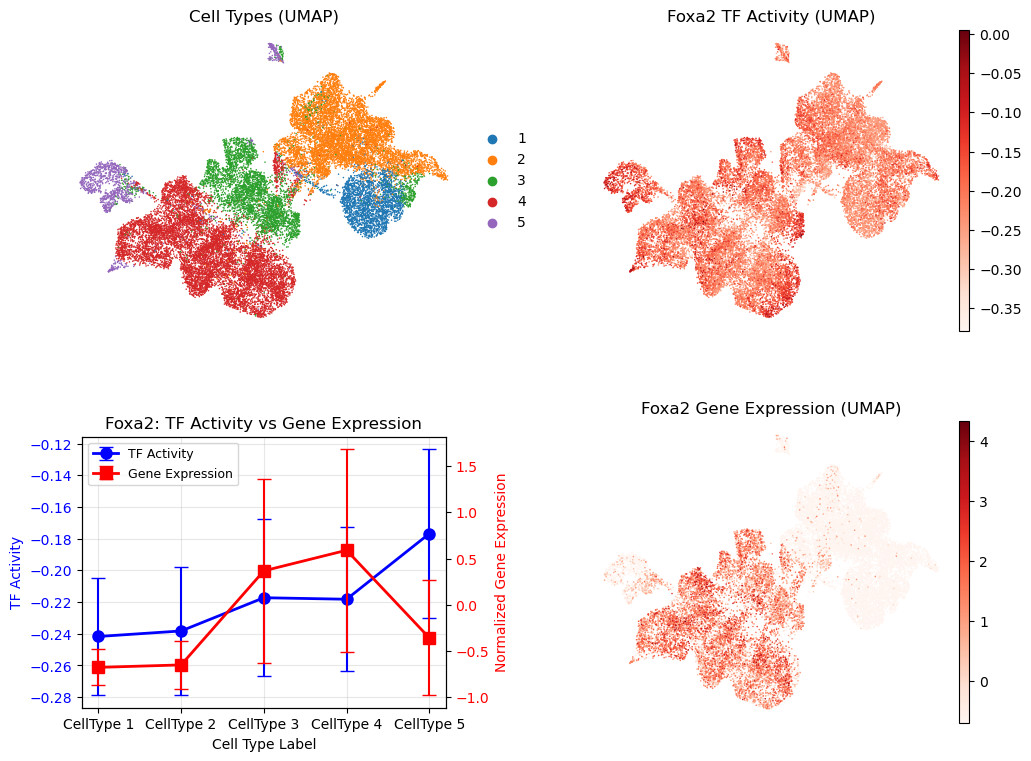

In [6]:

import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec

if 'X_umap' not in adata_RNA.obsm:
    print("Computing UMAP...")
    sc.tl.umap(adata_RNA)

foxa2_activity = TF_activity.loc['Foxa2'].reindex(adata_RNA.obs_names).values
adata_RNA.obs['Foxa2_activity'] = foxa2_activity

if 'Foxa2' in adata_RNA.var_names:
    foxa2_expr = adata_RNA[:, 'Foxa2'].X.toarray().flatten()
else:
    print("Foxa2 not found in var_names")
    foxa2_expr = np.zeros(len(adata_RNA))

labels = adata_RNA.obs['label'].values
unique_labels = sorted(set(labels))

activity_means, activity_stds = [], []
expr_means, expr_stds = [], []

for label in unique_labels:
    mask = (labels == label)
    activity_means.append(np.mean(foxa2_activity[mask]))
    activity_stds.append(np.std(foxa2_activity[mask]))
    expr_means.append(np.mean(foxa2_expr[mask]))
    expr_stds.append(np.std(foxa2_expr[mask]))

fig = plt.figure(figsize=(12, 9))
gs = GridSpec(2, 2, figure=fig, wspace=0.3, hspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
sc.pl.umap(
    adata_RNA,
    color='label',
    frameon=False,
    title='Cell Types',
    ax=ax1,
    show=False
)
ax1.set_title('Cell Types (UMAP)', fontsize=12)

ax2 = fig.add_subplot(gs[0, 1])
sc.pl.embedding(
    adata_RNA,
    basis='umap',
    color='Foxa2_activity',
    cmap='Reds',
    ax=ax2,
    show=False,
    frameon=False,
    title='Foxa2 TF Activity'
)
ax2.set_title('Foxa2 TF Activity (UMAP)', fontsize=12)

pos = gs[1, 0].get_position(fig)
center_x = (pos.x0 + pos.x1) / 2
center_y = (pos.y0 + pos.y1) / 2
width = (pos.x1 - pos.x0) * 0.9
height = (pos.y1 - pos.y0) * 0.9

ax4 = fig.add_axes([center_x - width/2, center_y - height/2, width, height])

x = unique_labels

ax4_left = ax4
ax4_left.errorbar(
    x, activity_means, yerr=activity_stds,
    marker='o', markersize=8, linewidth=2,
    color='blue', ecolor='blue', elinewidth=1.5, capsize=5,
    label='TF Activity'
)
ax4_left.set_xlabel('Cell Type Label', fontsize=10)
ax4_left.set_ylabel('TF Activity', fontsize=10, color='blue')
ax4_left.tick_params(axis='y', labelcolor='blue')
ax4_left.set_xticks(x)
ax4_left.set_xticklabels([f'CellType {i}' for i in x])
ax4_left.grid(True, alpha=0.3)

ax4_right = ax4_left.twinx()
ax4_right.errorbar(
    x, expr_means, yerr=expr_stds,
    marker='s', markersize=8, linewidth=2,
    color='red', ecolor='red', elinewidth=1.5, capsize=5,
    label='Gene Expression'
)
ax4_right.set_ylabel('Normalized Gene Expression', fontsize=10, color='red')
ax4_right.tick_params(axis='y', labelcolor='red')

lines1, labels1 = ax4_left.get_legend_handles_labels()
lines2, labels2 = ax4_right.get_legend_handles_labels()
ax4_left.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax4.set_title('Foxa2: TF Activity vs Gene Expression', fontsize=12)

pos = gs[1, 1].get_position(fig)
center_x = (pos.x0 + pos.x1) / 2
center_y = (pos.y0 + pos.y1) / 2
width = (pos.x1 - pos.x0) * 1
height = (pos.y1 - pos.y0) * 1

ax3 = fig.add_axes([center_x - width/2, center_y - height/2, width, height])

if 'Foxa2' in adata_RNA.var_names:
    sc.pl.embedding(
        adata_RNA,
        basis='umap',
        color='Foxa2',
        cmap='Reds',
        ax=ax3,
        show=False,
        frameon=False,
        title='Foxa2 Gene Expression',
        use_raw=False
    )
else:
    ax3.text(0.5, 0.5, 'Foxa2 not found', ha='center', va='center', fontsize=12)
ax3.set_title('Foxa2 Gene Expression (UMAP)', fontsize=12)

# ===== 保存 =====
plt.savefig('Foxa2_4panel_combined.pdf', dpi=300, bbox_inches='tight')
plt.savefig('Foxa2_4panel_combined.png', dpi=300, bbox_inches='tight')
plt.show()